## Load Dataset

In [1]:
import pandas as pd
import numpy as np  
import math
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from utils.kmean_evalution import evaluate_kmeans_overlap
from structures.grid import Grid, DensityGrid
from structures.r_tree_analyzer import RTreeSpatialAnalyzer



%matplotlib inline

import matplotlib.pyplot as plt

In [2]:
csv_data = pd.read_csv("datasets/points.csv")
latitudes = csv_data["normLatitude"]
longitudes = csv_data["normLongitude"]
maxLatitude = latitudes.max()
minLatitude = latitudes.min()
minLatitude = math.floor(minLatitude)
maxLatitude = math.ceil(maxLatitude)

maxLongitude = longitudes.max()
maxLongitude = math.ceil(maxLongitude)

minLongtitude = longitudes.min()
minLongtitude = math.floor(minLongtitude)

points_array = np.column_stack((longitudes, latitudes))
# initiate KMEANS
kmeans_data = csv_data[["normLatitude", "normLongitude"]].to_numpy()


## KMEANS Evaluation

In [3]:
overlap_score, labels, centers, radii = evaluate_kmeans_overlap(
    kmeans_data, n_clusters=7
)
print("KMEANS Score:", overlap_score)

KMEANS Score: 3.6810442012311464


## Grid Evalution

In [4]:
grid = Grid(
        xmin=minLongtitude, ymin=minLatitude, xmax=maxLongitude, ymax=maxLatitude, m=20
    )
    # assign points to grid
grid.fit(zip(csv_data["normLongitude"], csv_data["normLatitude"]))
    
print(f"Grid Score: {grid.compute_grid_overlap()}")

Grid Score: 0.48305882709502584


## Density Based Grid

In [5]:
density_grid = DensityGrid(
    xmin=minLongtitude, ymin=minLatitude, xmax=maxLongitude, ymax=maxLatitude, m=20
)
# assign points to grid
density_grid.fit(zip(csv_data["normLongitude"], csv_data["normLatitude"]))
print(f"Density Grid: {density_grid.compute_grid_overlap()}")

Density Grid: 0.5706381365504819


## R Tree Evaluation

R-tree built with 1000 entries.
Total computed overlap area among circles: 33.58


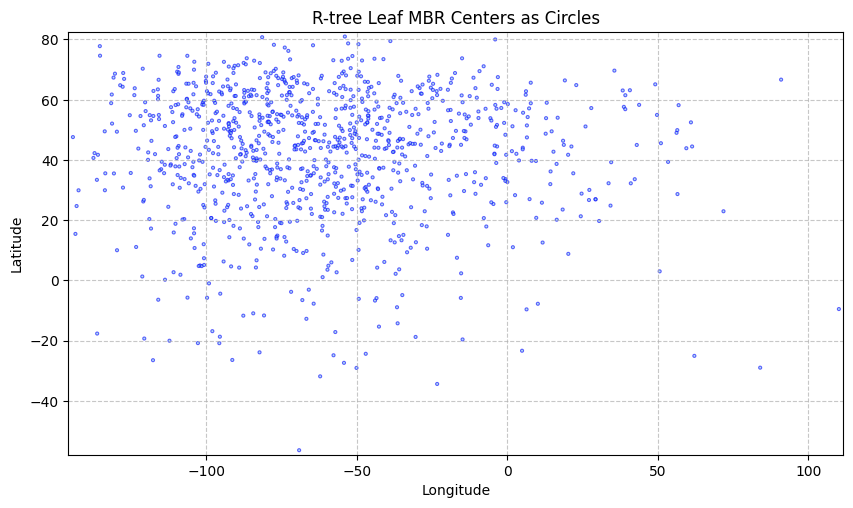

In [ ]:
csv_file_path = "./datasets/skewed_coords.csv"
analyzer = RTreeSpatialAnalyzer()
if analyzer.load_data_from_csv(csv_file_path,1000):
    total_overlap = analyzer.compute_overlap()
    print(f"Total computed overlap area among circles: {total_overlap:.2f}")
    # analyzer.visualize()

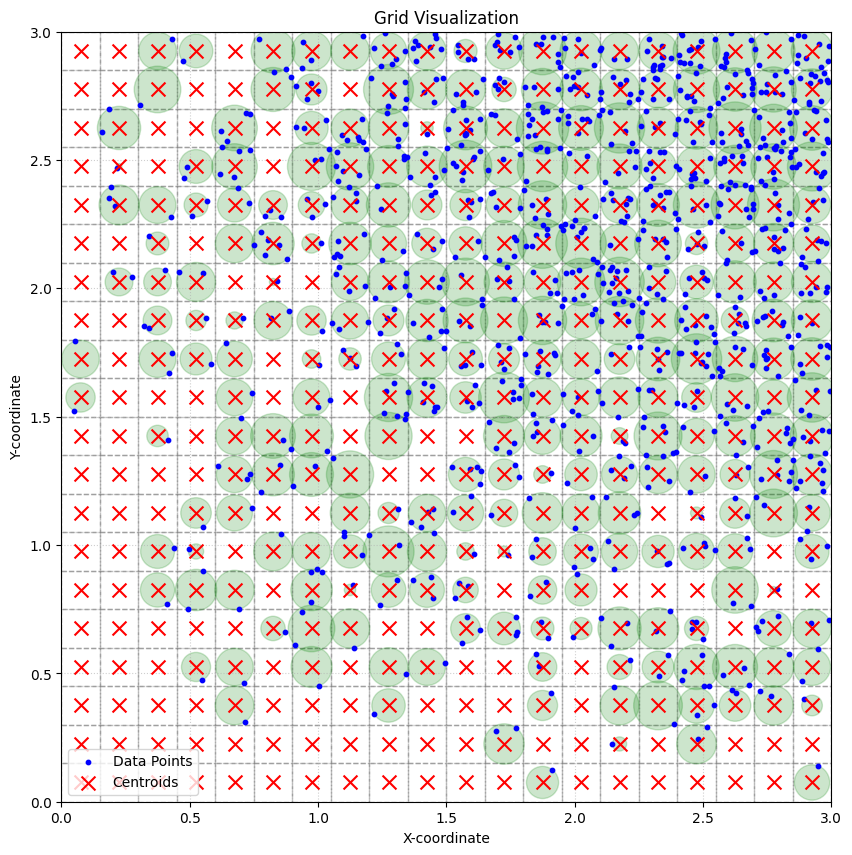

In [7]:
grid.visualize_grid()

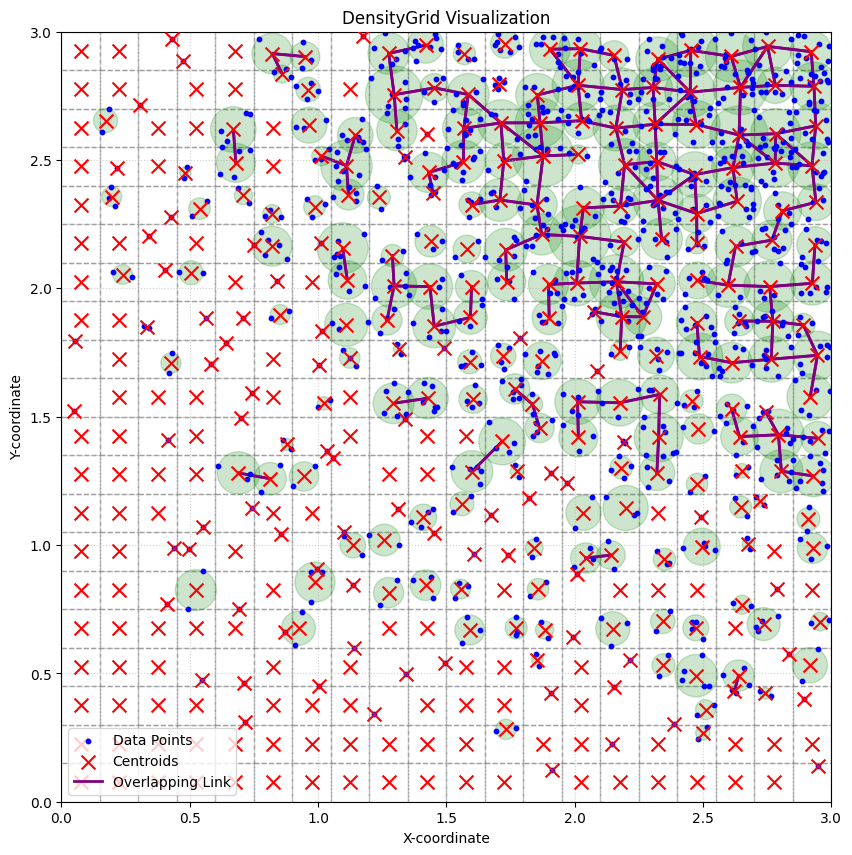

In [8]:
density_grid.visualize_grid()

In [9]:
kmeans_overlap = overlap_score  
grid_overlap = grid.compute_grid_overlap()
density_grid_overlap = density_grid.compute_grid_overlap()
r_tree_overlap = total_overlap

comparison_results = {
    "KMEANS Overlap": kmeans_overlap,
    "Grid Overlap": grid_overlap,
    "Density Grid Overlap": density_grid_overlap,
    "R-Tree Overlap": r_tree_overlap
}
import pandas as pd
comparison_df = pd.DataFrame(list(comparison_results.items()), columns=["Algorithm", "Overlap Score"])
display(comparison_df)

,Algorithm,Overlap Score
0,KMEANS Overlap,3.681044
1,Grid Overlap,0.483059
2,Density Grid Overlap,0.570638
3,R-Tree Overlap,33.584261
